In [1]:
import sys

sys.path.append("../..")

In [2]:
from xaikd import models, datasets, attributors, bases
from xaikd.utils import metrics

import numpy as np 

import torch

from torch.nn import functional as  F

import scipy

from tqdm import tqdm

import pandas as pd

from matplotlib import pyplot as plt

In [3]:
MODEL_NAME  = "cifar100-resnet18-p3"
DATASET_NAME = "cifar100-people"

model = models.get_model(MODEL_NAME)

dataset = datasets.construct(DATASET_NAME, num_training_samples=50)

val_loader = dataset.loader(train_split=False)
train_loader = dataset.loader(train_split=True)

We are building `cifar100-people` containing 5 fine classes
> baby (2)
> boy (11)
> girl (35)
> man (46)
> woman (98)


In [4]:
layer = "layer3"
arr_act, arr_ctx = attributors.extract_activation_context(
    model, 
    layer=layer, 
    dataset=dataset, 
    data_loader=train_loader,
    logit_modifier=attributors.OneClassEvidence(dataset)
)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:25<00:00,  6.43s/it]

layer3: output-dims=torch.Size([256, 8, 8])


In [5]:
teacher_acc = metrics.accuracy_with_subclasses(model, val_loader, dataset.selected_classes, dataset.transform_target, "cpu")

teacher_acc

0.5740000009536743

In [6]:
def pca(arr_x):
    _, eigvecs = np.linalg.eigh(arr_x.T@ arr_x  / arr_x.shape[0])
    
    eigvecs = eigvecs[:, ::-1]
    
    return eigvecs

U_pca = pca(arr_act)

In [7]:
def construct_A_from_pca(k):
    print(f"Constructing PCA(k={k})")
    Uk = U_pca[:, :k]
    return Uk @ Uk.T

In [8]:
def getID(k, W=None, mode='kT', verbose=False):
    '''
    ref: https://github.com/jerry-chee/ModelPreserveCompressionNN/blob/main/id_utils.py#L9
    calculates ID 
    mode: kT, WT (what to return)
    requires (d, n) format
    currently in numpy because pytorch doesn't support QR pivots
    k: number of columns
    Z: layer after nonlinearity
    ''' 
    print(f"Construct Interpolative Decom(k={k})")
    # hard-coded for now
    Z = arr_act
    
    assert(k <= Z.shape[1])
    # column-pivot QR
    R, P = scipy.linalg.qr((Z), mode='r', pivoting=True)
    if W is not None: Wk = W[:, P[0:k]]
    T = np.concatenate((
        np.identity(k),
        np.linalg.pinv(R[0:k, 0:k]) @ R[0:k, k:None]
        ), axis=1)
    T = T[:, np.argsort(P)]
    if mode == 'kT':
        eye = np.eye(T.shape[1])
        permat = eye[P[:k], :]

        if verbose:
            print("Permat.shape", permat.shape)
            print("T.shape", T.shape)

        A = T.T @ permat
#         print("A.shape", A.shape)
        return A
    
#     elif mode == 'WT' and W is not None:
#         return Wk, T
    else:
        raise NotImplementedError
        
getID(10)

Construct Interpolative Decom(k=10)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [9]:
def id_and_pca(k):
    
    A = getID(k)
    
    B = construct_A_from_pca(k)
    
    return B @ A 

id_and_pca(10)

Construct Interpolative Decom(k=10)
Constructing PCA(k=10)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [10]:
torch.manual_seed(1)
basis_prcaabs = bases.PRCAAbs("prca-abs", centering=False)

basis_prcaabs.fit(arr_act @ U_pca, arr_ctx @ U_pca, mean=None)

[mode=abs,beta=0.0,device=cpu]: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 256/256 [03:02<00:00,  1.40it/s]


(array([[-9.1338694e-01,  1.3455096e-01,  3.7191620e-01, ...,
         -2.4081646e-05,  2.3642578e-03, -5.3076692e-05],
        [ 2.1587548e-01,  8.6557502e-01,  1.6713984e-01, ...,
         -2.4779623e-03,  3.7074143e-03,  5.7966779e-03],
        [ 4.8428964e-02, -4.9779061e-02,  6.0007274e-02, ...,
         -4.4619134e-03,  5.9611076e-03, -8.8637266e-03],
        ...,
        [ 1.6789330e-02,  7.4885585e-03,  4.2298928e-02, ...,
         -1.8494144e-02, -1.4547688e-01, -3.6312904e-02],
        [ 8.0096042e-03, -3.3112713e-03,  2.2489954e-02, ...,
          1.0405108e-02, -1.0409608e-01, -1.3832113e-01],
        [ 1.0808896e-02, -1.5195143e-02,  3.3989064e-02, ...,
          1.7259657e-01, -3.5372887e-02,  1.6764094e-01]], dtype=float32),
 array([1.49004606, 1.34870535, 0.20785177, 0.96442747, 0.68735595,
        0.7413756 , 0.63263071, 0.61802202, 0.61356853, 0.52765499,
        0.43627335, 0.44498045, 0.40965236, 0.46151527, 0.46142674,
        0.4071739 , 0.35353291, 0.39236785, 0.

In [11]:
basis_prcaabs.artifact["eigvecs"]

array([[-9.1338694e-01,  1.3455096e-01,  3.7191620e-01, ...,
        -2.4081646e-05,  2.3642578e-03, -5.3076692e-05],
       [ 2.1587548e-01,  8.6557502e-01,  1.6713984e-01, ...,
        -2.4779623e-03,  3.7074143e-03,  5.7966779e-03],
       [ 4.8428964e-02, -4.9779061e-02,  6.0007274e-02, ...,
        -4.4619134e-03,  5.9611076e-03, -8.8637266e-03],
       ...,
       [ 1.6789330e-02,  7.4885585e-03,  4.2298928e-02, ...,
        -1.8494144e-02, -1.4547688e-01, -3.6312904e-02],
       [ 8.0096042e-03, -3.3112713e-03,  2.2489954e-02, ...,
         1.0405108e-02, -1.0409608e-01, -1.3832113e-01],
       [ 1.0808896e-02, -1.5195143e-02,  3.3989064e-02, ...,
         1.7259657e-01, -3.5372887e-02,  1.6764094e-01]], dtype=float32)

In [12]:
def id_and_prca_abs(k):
    
    A = getID(k)
    
    B = basis_prcaabs.artifact["eigvecs"]
    B = B[:, :k]
    B = U_pca @ B @ B.T @ U_pca.T
    return B @ A 

id_and_prca_abs(10)

Construct Interpolative Decom(k=10)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [13]:
def sprectral_prunning_with_rel(k, tau=0.001, verbose=False):
    print(f"Construct Sprectral Prunning with Rel(k={k}, tau={tau})")
    R = arr_act * arr_ctx
    
    R = np.mean(R, axis=0)
    Rabs = np.abs(R)
    
    sorted_dim_indices = np.argsort(-Rabs)
    
    J = sorted_dim_indices[:k]
    
    if verbose:
        print("max(|R|)", np.abs(R).max(),  np.abs(R).min())

        print(J)
        print(R[J])
    
    
    cov = np.cov(arr_act.T)
    d = cov.shape[0]
    
    cov_FJ = cov[:, J]
    cov_JJ = cov_FJ[J, :]
    
    
    A = cov_FJ @ np.linalg.inv(cov_JJ + tau * np.eye(cov_JJ.shape[0]))
    
    P = np.eye(d)[J, :]    
    
    return A @ P

sprectral_prunning_with_rel(10, verbose=True)

Construct Sprectral Prunning with Rel(k=10, tau=0.001)
max(|R|) 0.003648232 2.1949786e-06
[ 22 250 215 127 145  73 165 243 229  17]
[0.00364823 0.00346861 0.00286609 0.00262752 0.00254552 0.00230447
 0.00220465 0.00208794 0.00207756 0.00199325]


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [14]:
def pruning_lrp(k, verbose=False):
    print(f"Construct Prunning LRP(k={k})")
    R = arr_act * arr_ctx
    
    R = np.mean(R, axis=0)
    Rabs = np.abs(R)
    
    sorted_dim_indices = np.argsort(-Rabs)
    d = len(sorted_dim_indices)
    J = sorted_dim_indices[:k]
    
    
    P = np.eye(d)[J, :]  
    print(P.shape)
    
    return P.T @ P

pruning_lrp(10, verbose=True).shape

Construct Prunning LRP(k=10)
(10, 256)


(256, 256)

In [15]:
def pruning_lrp_with_A(k, verbose=False, iters=1000):
    print(f"Construct Prunning LRP++(k={k})")
    R = arr_act * arr_ctx
    
#     Rmean = np.mean(R, axis=0)
#     Rabs = np.abs(Rmean)
    
#     sorted_dim_indices = np.argsort(-Rabs)
    

    
    R, P = scipy.linalg.qr(arr_act, mode='r', pivoting=True)

    d = len(P)

    T = np.concatenate((
        np.identity(k),
        np.linalg.pinv(R[0:k, 0:k]) @ R[0:k, k:None]
        ), axis=1)
    T = T[:, np.argsort(P)]
    
    J = P[:k]

    
    lr = 1.0
    
    torch.manual_seed(1)
    B = torch.from_numpy(T).float()
    B.requires_grad_(True)
    
    permat = np.eye(d)[J, :]  
    
    
    act = torch.from_numpy(arr_act)
    ctx = torch.from_numpy(arr_ctx)
    
    rel = torch.from_numpy(R).sum(dim=1)
    
    for i in range(iters):
        B.grad = None
        aj = act[:, J]
        cj = ctx
        
        relj = ((aj@B) * (cj)).sum(dim=1)
#         print(relj.shape)
        
        loss = (rel - relj)**2
        loss = loss.mean()
        
        loss.backward()
        
        B.data = (B - lr * B.grad).data
    
        
        if verbose:
#             print(A.grad)
            print(i, loss)
#         break

    B = B.detach().numpy()
        
    
    P = np.eye(d)[J, :]  
    
    A =  B.T @ permat
    
    
    return A

# pruning_lrp_with_A(10, verbose=True).shape

In [16]:
def basis_factory(name, k):
    
    if name == "pca":
        return construct_A_from_pca(k)
    elif name == "id":
        return getID(k)
    elif name == "specprune-rel":
        return sprectral_prunning_with_rel(k)
    elif name == "prunning-lrp":
        return pruning_lrp(k)
    elif name == "id-with-prca-abs":
        return id_and_prca_abs(k)
    else:
        raise ValueError(f"{name} doesn't exist")

In [17]:
def construct_fh_hook_projection(A): 
    
    A = torch.from_numpy(A).float()
    
    A = A.unsqueeze(2).unsqueeze(3)

    def fh(mod, input, output):
        assert isinstance(output, torch.Tensor)

        projected = F.conv2d(output, A)

        return projected 

    return fh

def compute_acc(A):
    
    try:
        module = getattr(model, layer)[-1]
        
        hook = module.register_forward_hook(construct_fh_hook_projection(A))
        
        acc = metrics.accuracy_with_subclasses(model, val_loader, dataset.selected_classes, dataset.transform_target, "cpu")
        
        print(f"acc={acc:.4f}")
    finally:
        hook.remove()
        
    return acc
        
compute_acc(construct_A_from_pca(100))

Constructing PCA(k=100)
acc=0.5880


0.5879999995231628

In [18]:
compute_acc(getID(50))

Construct Interpolative Decom(k=50)
acc=0.4920


0.492000013589859

In [19]:
compute_acc(id_and_prca_abs(50))

Construct Interpolative Decom(k=50)
acc=0.4720


0.47200000286102295

In [20]:
compute_acc(sprectral_prunning_with_rel(50, tau=0.0001))

Construct Sprectral Prunning with Rel(k=50, tau=0.0001)
acc=0.4540


0.45399999618530273

In [21]:
compute_acc(pruning_lrp_with_A(50, iters=10))

Construct Prunning LRP++(k=50)
acc=0.2600


0.25999999046325684

# Viz

In [22]:
def estimate_stats(approach):
    rows = []
    for k in tqdm([1, 10, 50, 100, 125, 150, 175, 200, 256]):

        acc = compute_acc(
            basis_factory(approach, k)
        )

        rows.append(dict(name=approach, k=k, acc=acc))

    return pd.DataFrame(rows)

df_pca = estimate_stats("pca")

  0%|                                                                                                                                                                                                                                                                     | 0/9 [00:00<?, ?it/s]

Constructing PCA(k=1)


 11%|████████████████████████████                                                                                                                                                                                                                                 | 1/9 [00:03<00:29,  3.75s/it]

acc=0.2000
Constructing PCA(k=10)


 22%|████████████████████████████████████████████████████████▏                                                                                                                                                                                                    | 2/9 [00:07<00:27,  3.86s/it]

...

acc=0.5740
Constructing PCA(k=200)


 89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                            | 8/9 [00:30<00:03,  3.83s/it]

acc=0.5760
Constructing PCA(k=256)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:34<00:00,  3.87s/it]

acc=0.5740


In [23]:
df_id = estimate_stats("id")

  0%|                                                                                                                                                                                                                                                                     | 0/9 [00:00<?, ?it/s]

Construct Interpolative Decom(k=1)


 11%|████████████████████████████                                                                                                                                                                                                                                 | 1/9 [00:05<00:40,  5.02s/it]

acc=0.2040
Construct Interpolative Decom(k=10)


 22%|████████████████████████████████████████████████████████▏                                                                                                                                                                                                    | 2/9 [00:09<00:31,  4.49s/it]

...

acc=0.5760
Construct Interpolative Decom(k=200)


 89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                            | 8/9 [00:32<00:03,  3.91s/it]

acc=0.5800
Construct Interpolative Decom(k=256)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:36<00:00,  4.01s/it]

acc=0.5740


In [24]:
# df_spectral = estimate_stats("specprune-rel")

In [25]:
df_prunning_lrp = estimate_stats("prunning-lrp")

  0%|                                                                                                                                                                                                                                                                     | 0/9 [00:00<?, ?it/s]

Construct Prunning LRP(k=1)
(1, 256)


 11%|████████████████████████████                                                                                                                                                                                                                                 | 1/9 [00:04<00:34,  4.26s/it]

acc=0.2000
Construct Prunning LRP(k=10)
(10, 256)


 22%|████████████████████████████████████████████████████████▏                                                                                                                                                                                                    | 2/9 [00:07<00:27,  3.95s/it]

...

acc=0.5260
Construct Prunning LRP(k=200)
(200, 256)


 89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                            | 8/9 [00:31<00:03,  3.82s/it]

acc=0.5520
Construct Prunning LRP(k=256)
(256, 256)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:34<00:00,  3.86s/it]

acc=0.5740


In [26]:
df_id_prca_abs =estimate_stats("id-with-prca-abs")

  0%|                                                                                                                                                                                                                                                                     | 0/9 [00:00<?, ?it/s]

Construct Interpolative Decom(k=1)


 11%|████████████████████████████                                                                                                                                                                                                                                 | 1/9 [00:04<00:36,  4.51s/it]

acc=0.1960
Construct Interpolative Decom(k=10)


 22%|████████████████████████████████████████████████████████▏                                                                                                                                                                                                    | 2/9 [00:08<00:28,  4.12s/it]

...

acc=0.5780
Construct Interpolative Decom(k=200)


 89%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▉                            | 8/9 [00:32<00:04,  4.01s/it]

acc=0.5860
Construct Interpolative Decom(k=256)


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 9/9 [00:36<00:00,  4.04s/it]

acc=0.5740


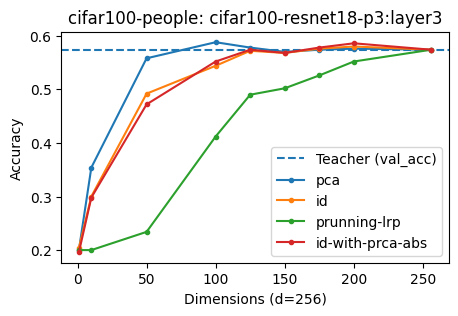

In [27]:
def viz(df):
    plt.figure(figsize=(5, 3))
    d = arr_act.shape[1]
    approaches = df.name.unique()
    plt.title(f"{DATASET_NAME}: {MODEL_NAME}:{layer}")
    plt.axhline(teacher_acc, ls="--", label="Teacher (val_acc)")
    for aix, name in enumerate(approaches):
        
        _df = df[df.name == name]
        
        plt.plot(_df.k, _df.acc, label=name, marker=".")
    plt.legend()
    plt.xlabel(f"Dimensions (d={d})")
    plt.ylabel("Accuracy")
 
viz(pd.concat([
    df_pca,
    df_id,
#     df_spectral,
    df_prunning_lrp,
    df_id_prca_abs,

]))